
# Importações

In [9]:
import io
import os
import random
import time
import warnings

import numpy as np
import pandas as pd
import shap
from IPython.core.display import Image
from bs4 import BeautifulSoup
from selenium.webdriver.common.by import By
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager

SEED = 100


def reset_seed(rnd_seed=SEED):
    os.environ['PYTHONHASHSEED'] = '0'
    random.seed(rnd_seed)
    np.random.seed(rnd_seed)


warnings.filterwarnings("ignore")
reset_seed()

# Carregar Datasets

In [10]:
df = pd.read_csv("./dados/dados_normalizados_lagados.csv", sep=';', decimal='.')
df

,CONSUMO,DATA,TEMP_MIN_MÉD_MENS,TEMP_MÉD_MIN_MENS,TEMP_MÉD_MÉD_MENS,TEMP_MÉD_MAX_MENS,TEMP_MÉD_ACC_MENS,TEMP_MAX_MÉD_MENS,PRECIPITAÇÃO_MÉD_MENS,TEMP_MIN_MIN_MENS,...,LAG_03,LAG_04,LAG_05,LAG_06,LAG_07,LAG_08,LAG_09,LAG_10,LAG_11,LAG_12
0,0.615105,2016-02-29,19,22,25,28,734,33,4,19,...,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886,0.502037
1,0.711047,2016-03-31,12,17,22,28,685,32,3,12,...,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078,0.846886
2,0.633361,2016-04-30,4,9,23,28,702,33,2,4,...,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844,0.643078
3,0.406291,2016-05-31,4,11,16,22,490,27,9,4,...,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551,0.530844
4,0.362467,2016-06-30,-1,7,14,20,408,27,3,-1,...,0.711047,0.615105,0.424204,0.580507,0.570938,0.553762,0.386907,0.331354,0.302547,0.384551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090,0.359224,2024-06-30,0,8,17,20,499,26,1,0,...,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248,0.743880
2091,1.000000,2024-07-31,1,9,13,18,413,25,6,1,...,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038,0.553248
2092,0.940871,2024-08-31,-3,7,15,21,468,31,1,-3,...,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059,0.839038
2093,0.788386,2024-09-30,10,13,20,24,591,34,3,10,...,0.359224,0.352866,0.680301,0.990145,0.803327,0.457985,0.822613,0.794744,0.559818,0.747059


## Divisão dos Dados

In [11]:
dataframes = []

for campus, dados in df.sort_values("DATA").groupby("CAMPUS"):
    dados_treino, dados_teste = train_test_split(dados, test_size=12, shuffle=False)

    dataframes.append(dados_treino)

df = pd.concat(dataframes, ignore_index=True)


# SHAP Global

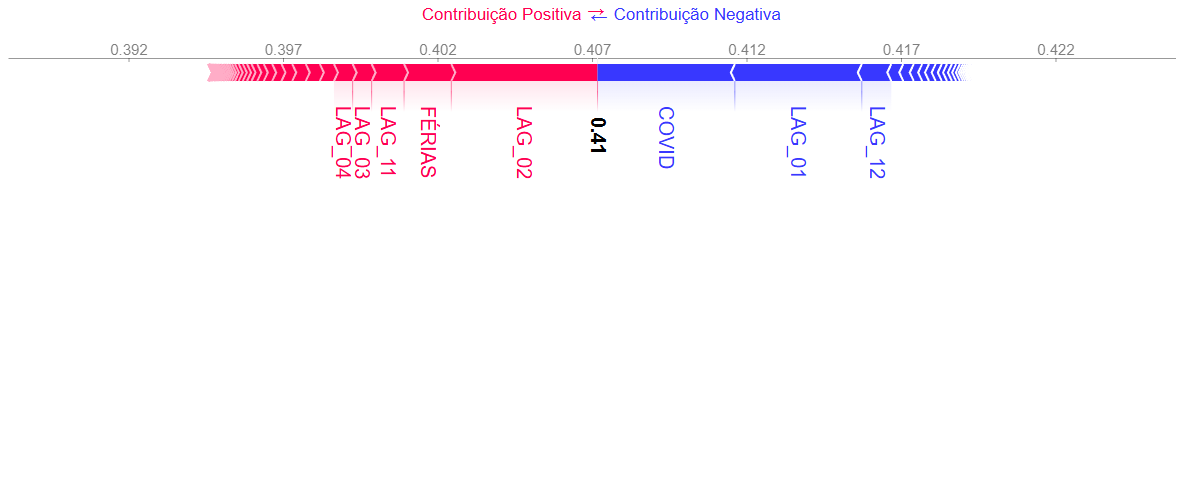

In [12]:
shap.initjs()
dados = df.reset_index(drop=True)

x = dados.drop(columns=["DATA", "CAMPUS", "REGIÃO", "CONSUMO"])
y = dados["CONSUMO"]

modelo = RandomForestRegressor(random_state=SEED)
modelo.fit(x, y)
explainer = shap.Explainer(modelo)
shap_rf = explainer(x)

base_values_rf = pd.DataFrame(index=x.columns)
values_rf = pd.DataFrame(index=x.columns)
data_rf = pd.DataFrame(index=x.columns)

for sample in shap_rf:
    base_values_rf = pd.concat([base_values_rf, pd.Series(sample.base_values, index=x.columns)], axis=1)
    values_rf = pd.concat([values_rf, pd.Series(sample.values, index=x.columns)], axis=1)
    data_rf = pd.concat([data_rf, pd.Series(sample.data, index=x.columns)], axis=1)

force = shap.plots.force(base_value=base_values_rf.mean(axis=1).to_numpy(),
                         shap_values=values_rf.mean(axis=1).to_numpy(),
                         text_rotation=90,
                         plot_cmap=["#ff0051", "#3838ff"],
                         features=data_rf.mean(axis=1).to_numpy().astype(int),
                         feature_names=x.columns,
                         show=True)

shap.save_html(f"resultados/shap/SHAP GLOBAL.html", plot=force, full_html=True)

with open(f"resultados/shap/_HTML BASE.html", "r", encoding="utf-8") as file:
    base = BeautifulSoup(file, "html.parser")

with open(f"resultados/shap/SHAP GLOBAL.html", "r", encoding="utf-8") as file:
    html = BeautifulSoup(file, "html.parser")

for texto in html.find_all(text=True):
    texto.replace_with(texto.replace("f(x)", ""))

base.body.replace_with(html.body)
with io.open(f"resultados/shap/SHAP GLOBAL.html", "w", encoding="utf-8") as file:
    file.write(str(base))

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--headless")  # Roda o Chrome sem abrir uma janela
chrome_options.add_argument("--window-size=1200,650")  # Define um tamanho para a janela virtual

service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # Converte o caminho relativo para um absoluto (necessário para o navegador)
    url = 'file:///' + os.path.abspath(f"resultados/shap/SHAP GLOBAL.html")
    driver.get(url)

    # Espera 1 segundo para o JavaScript renderizar o gráfico
    time.sleep(1)

    # Tira a screenshot e salva
    caminho_completo_saida = os.path.join(f"resultados/shap/", f"SHAP GLOBAL.png")
    driver.save_screenshot(caminho_completo_saida)


finally:
    # Fecha o navegador e remove o arquivo temporário
    driver.quit()
    if os.path.exists(f"resultados/shap/SHAP GLOBAL.html"):
        os.remove(f"resultados/shap/SHAP GLOBAL.html")

display(Image(filename=os.path.join("resultados/shap/", "SHAP GLOBAL.png")))


# SHAP - Férias

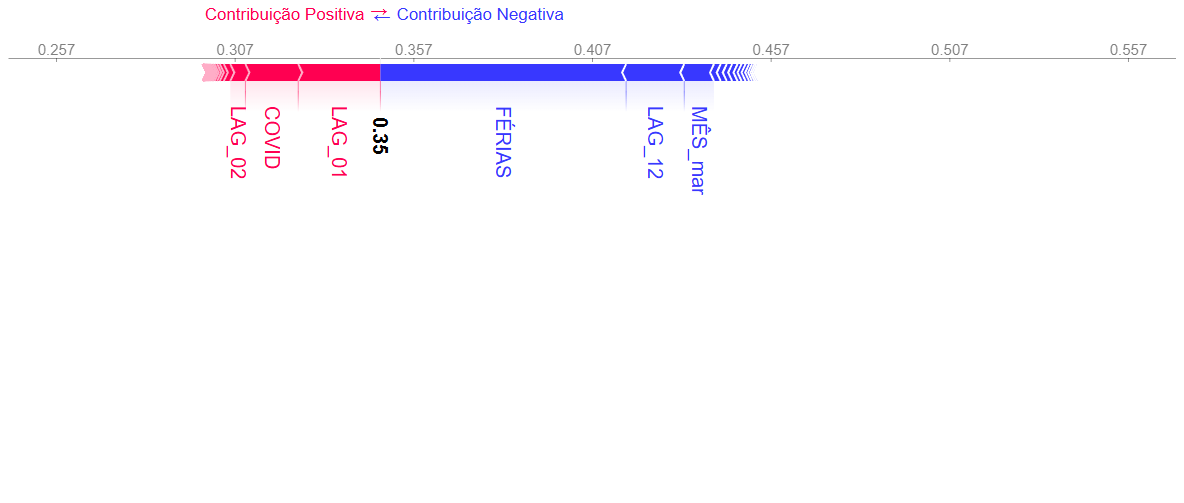

In [13]:
shap.initjs()
dados = df.reset_index(drop=True)

x = dados.drop(columns=["DATA", "CAMPUS", "REGIÃO", "CONSUMO"])
y = dados["CONSUMO"]

modelo = RandomForestRegressor(random_state=SEED)
modelo.fit(x, y)
explainer = shap.Explainer(modelo)
shap_rf = explainer(x[x["FÉRIAS"] > 0])

base_values_rf = pd.DataFrame(index=x.columns)
values_rf = pd.DataFrame(index=x.columns)
data_rf = pd.DataFrame(index=x.columns)

for sample in shap_rf:
    base_values_rf = pd.concat([base_values_rf, pd.Series(sample.base_values, index=x.columns)], axis=1)
    values_rf = pd.concat([values_rf, pd.Series(sample.values, index=x.columns)], axis=1)
    data_rf = pd.concat([data_rf, pd.Series(sample.data, index=x.columns)], axis=1)

force = shap.plots.force(base_value=base_values_rf.mean(axis=1).to_numpy(),
                         shap_values=values_rf.mean(axis=1).to_numpy(),
                         text_rotation=90,
                         plot_cmap=["#ff0051", "#3838ff"],
                         features=data_rf.mean(axis=1).to_numpy().astype(int),
                         feature_names=x.columns,
                         show=True)

shap.save_html(f"resultados/shap/SHAP FÉRIAS.html", plot=force, full_html=True)

with open(f"resultados/shap/_HTML BASE.html", "r", encoding="utf-8") as file:
    base = BeautifulSoup(file, "html.parser")

with open(f"resultados/shap/SHAP FÉRIAS.html", "r", encoding="utf-8") as file:
    html = BeautifulSoup(file, "html.parser")

for texto in html.find_all(text=True):
    texto.replace_with(texto.replace("f(x)", ""))

base.body.replace_with(html.body)
with io.open(f"resultados/shap/SHAP FÉRIAS.html", "w", encoding="utf-8") as file:
    file.write(str(base))

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--headless")  # Roda o Chrome sem abrir uma janela
chrome_options.add_argument("--window-size=1200,650")  # Define um tamanho para a janela virtual

service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # Converte o caminho relativo para um absoluto (necessário para o navegador)
    url = 'file:///' + os.path.abspath(f"resultados/shap/SHAP FÉRIAS.html")
    driver.get(url)

    # Espera 1 segundo para o JavaScript renderizar o gráfico
    time.sleep(1)

    # Tira a screenshot e salva
    caminho_completo_saida = os.path.join(f"resultados/shap/", f"SHAP FÉRIAS.png")
    driver.save_screenshot(caminho_completo_saida)


finally:
    # Fecha o navegador e remove o arquivo temporário
    driver.quit()
    if os.path.exists(f"resultados/shap/SHAP FÉRIAS.html"):
        os.remove(f"resultados/shap/SHAP FÉRIAS.html")

display(Image(filename=os.path.join("resultados/shap/", "SHAP FÉRIAS.png")))

# SHAP - COVID

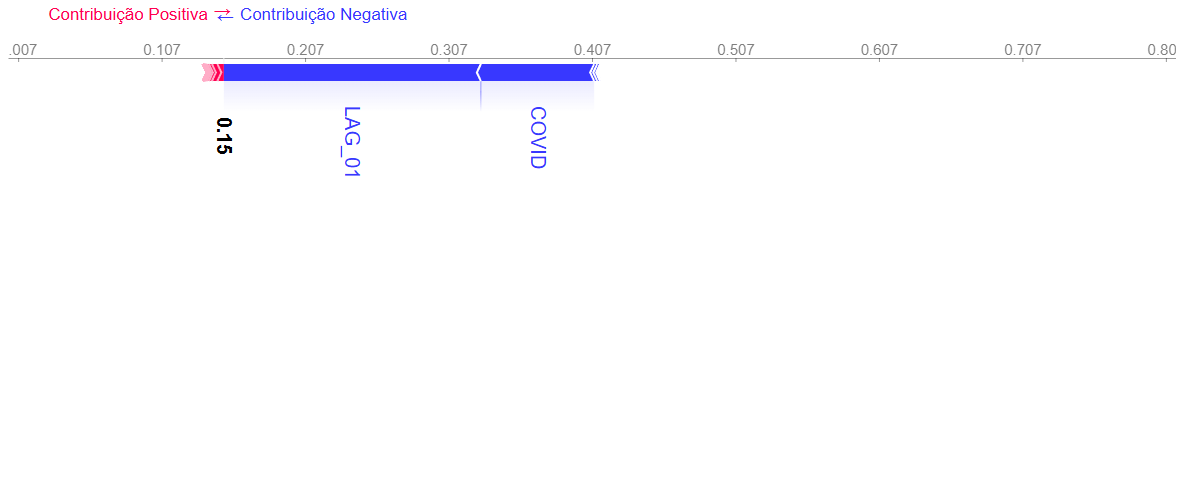

In [14]:
shap.initjs()
dados = df.reset_index(drop=True)

x = dados.drop(columns=["DATA", "CAMPUS", "REGIÃO", "CONSUMO"])
y = dados["CONSUMO"]

modelo = RandomForestRegressor(random_state=SEED)
modelo.fit(x, y)
explainer = shap.Explainer(modelo)
shap_rf = explainer(x[x["COVID"] > 0])

base_values_rf = pd.DataFrame(index=x.columns)
values_rf = pd.DataFrame(index=x.columns)
data_rf = pd.DataFrame(index=x.columns)

for sample in shap_rf:
    base_values_rf = pd.concat([base_values_rf, pd.Series(sample.base_values, index=x.columns)], axis=1)
    values_rf = pd.concat([values_rf, pd.Series(sample.values, index=x.columns)], axis=1)
    data_rf = pd.concat([data_rf, pd.Series(sample.data, index=x.columns)], axis=1)

force = shap.plots.force(base_value=base_values_rf.mean(axis=1).to_numpy(),
                         shap_values=values_rf.mean(axis=1).to_numpy(),
                         text_rotation=90,
                         plot_cmap=["#ff0051", "#3838ff"],
                         features=data_rf.mean(axis=1).to_numpy().astype(int),
                         feature_names=x.columns,
                         show=True)

shap.save_html(f"resultados/shap/SHAP COVID.html", plot=force, full_html=True)

with open(f"resultados/shap/_HTML BASE.html", "r", encoding="utf-8") as file:
    base = BeautifulSoup(file, "html.parser")

with open(f"resultados/shap/SHAP COVID.html", "r", encoding="utf-8") as file:
    html = BeautifulSoup(file, "html.parser")

for texto in html.find_all(text=True):
    texto.replace_with(texto.replace("f(x)", ""))

base.body.replace_with(html.body)
with io.open(f"resultados/shap/SHAP COVID.html", "w", encoding="utf-8") as file:
    file.write(str(base))

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--headless")  # Roda o Chrome sem abrir uma janela
chrome_options.add_argument("--window-size=1200,650")  # Define um tamanho para a janela virtual

service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # Converte o caminho relativo para um absoluto (necessário para o navegador)
    url = 'file:///' + os.path.abspath(f"resultados/shap/SHAP COVID.html")
    driver.get(url)

    # Espera 1 segundo para o JavaScript renderizar o gráfico
    time.sleep(1)

    # Tira a screenshot e salva
    caminho_completo_saida = os.path.join(f"resultados/shap/", f"SHAP COVID.png")
    driver.save_screenshot(caminho_completo_saida)


finally:
    # Fecha o navegador e remove o arquivo temporário
    driver.quit()
    if os.path.exists(f"resultados/shap/SHAP COVID.html"):
        os.remove(f"resultados/shap/SHAP COVID.html")

display(Image(filename=os.path.join("resultados/shap/", "SHAP COVID.png")))

# SHAP - Frio

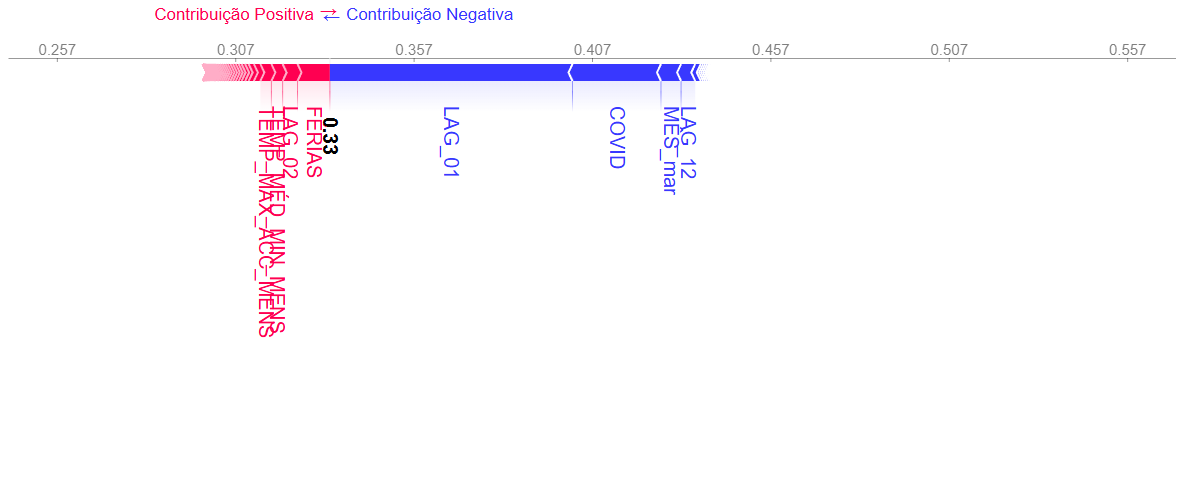

In [23]:
shap.initjs()
dados = df.reset_index(drop=True)

x = dados.drop(columns=["DATA", "CAMPUS", "REGIÃO", "CONSUMO"])
y = dados["CONSUMO"]

modelo = RandomForestRegressor(random_state=SEED)
modelo.fit(x, y)
explainer = shap.Explainer(modelo)
shap_rf = explainer(x[(x["TEMP_MIN_MIN_MENS"] < 0) & (x["FÉRIAS"] == 0)])

base_values_rf = pd.DataFrame(index=x.columns)
values_rf = pd.DataFrame(index=x.columns)
data_rf = pd.DataFrame(index=x.columns)

for sample in shap_rf:
    base_values_rf = pd.concat([base_values_rf, pd.Series(sample.base_values, index=x.columns)], axis=1)
    values_rf = pd.concat([values_rf, pd.Series(sample.values, index=x.columns)], axis=1)
    data_rf = pd.concat([data_rf, pd.Series(sample.data, index=x.columns)], axis=1)

force = shap.plots.force(base_value=base_values_rf.mean(axis=1).to_numpy(),
                         shap_values=values_rf.mean(axis=1).to_numpy(),
                         text_rotation=90,
                         plot_cmap=["#ff0051", "#3838ff"],
                         features=data_rf.mean(axis=1).to_numpy().astype(int),
                         feature_names=x.columns,
                         show=True)

shap.save_html(f"resultados/shap/SHAP FRIO.html", plot=force, full_html=True)

with open(f"resultados/shap/_HTML BASE.html", "r", encoding="utf-8") as file:
    base = BeautifulSoup(file, "html.parser")

with open(f"resultados/shap/SHAP FRIO.html", "r", encoding="utf-8") as file:
    html = BeautifulSoup(file, "html.parser")

for texto in html.find_all(text=True):
    texto.replace_with(texto.replace("f(x)", ""))

base.body.replace_with(html.body)
with io.open(f"resultados/shap/SHAP FRIO.html", "w", encoding="utf-8") as file:
    file.write(str(base))

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--headless")  # Roda o Chrome sem abrir uma janela
chrome_options.add_argument("--window-size=1200,650")  # Define um tamanho para a janela virtual

service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # Converte o caminho relativo para um absoluto (necessário para o navegador)
    url = 'file:///' + os.path.abspath(f"resultados/shap/SHAP FRIO.html")
    driver.get(url)

    # Espera 1 segundo para o JavaScript renderizar o gráfico
    time.sleep(1)

    # Tira a screenshot e salva
    caminho_completo_saida = os.path.join(f"resultados/shap/", f"SHAP FRIO.png")
    driver.save_screenshot(caminho_completo_saida)


finally:
    # Fecha o navegador e remove o arquivo temporário
    driver.quit()
    if os.path.exists(f"resultados/shap/SHAP FRIO.html"):
        os.remove(f"resultados/shap/SHAP FRIO.html")

display(Image(filename=os.path.join("resultados/shap/", "SHAP FRIO.png")))

# SHAP - Calor

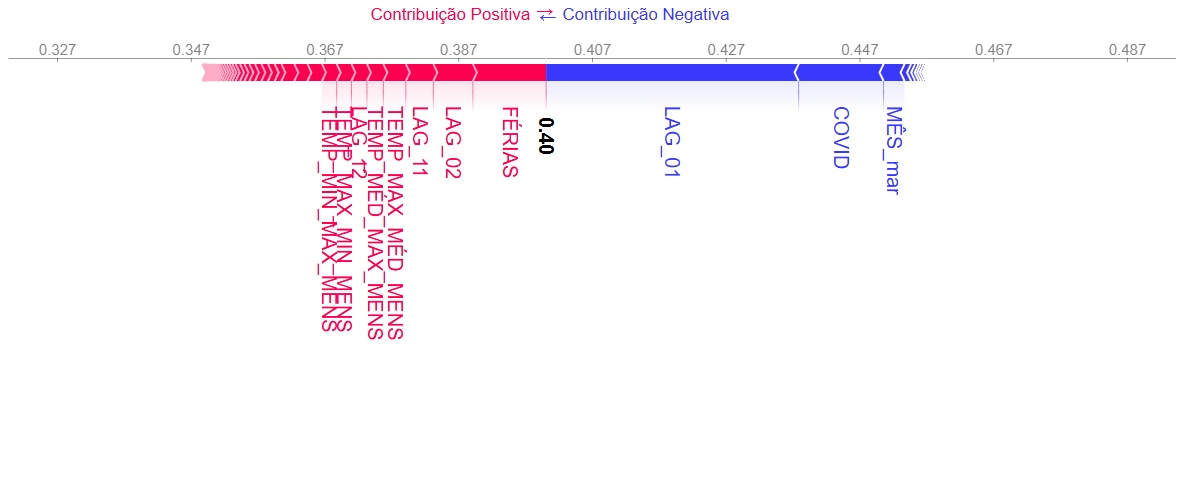

In [21]:
shap.initjs()
dados = df.reset_index(drop=True)

x = dados.drop(columns=["DATA", "CAMPUS", "REGIÃO", "CONSUMO"])
y = dados["CONSUMO"]

modelo = RandomForestRegressor(random_state=SEED)
modelo.fit(x, y)
explainer = shap.Explainer(modelo)
shap_rf = explainer(x[(x["TEMP_MAX_MAX_MENS"] > 35) & (x["FÉRIAS"] == 0)])

base_values_rf = pd.DataFrame(index=x.columns)
values_rf = pd.DataFrame(index=x.columns)
data_rf = pd.DataFrame(index=x.columns)

for sample in shap_rf:
    base_values_rf = pd.concat([base_values_rf, pd.Series(sample.base_values, index=x.columns)], axis=1)
    values_rf = pd.concat([values_rf, pd.Series(sample.values, index=x.columns)], axis=1)
    data_rf = pd.concat([data_rf, pd.Series(sample.data, index=x.columns)], axis=1)

force = shap.plots.force(base_value=base_values_rf.mean(axis=1).to_numpy(),
                         shap_values=values_rf.mean(axis=1).to_numpy(),
                         text_rotation=90,
                         plot_cmap=["#ff0051", "#3838ff"],
                         features=data_rf.mean(axis=1).to_numpy().astype(int),
                         feature_names=x.columns,
                         show=True)

shap.save_html(f"resultados/shap/SHAP CALOR.html", plot=force, full_html=True)

with open(f"resultados/shap/_HTML BASE.html", "r", encoding="utf-8") as file:
    base = BeautifulSoup(file, "html.parser")

with open(f"resultados/shap/SHAP CALOR.html", "r", encoding="utf-8") as file:
    html = BeautifulSoup(file, "html.parser")

for texto in html.find_all(text=True):
    texto.replace_with(texto.replace("f(x)", ""))

base.body.replace_with(html.body)
with io.open(f"resultados/shap/SHAP CALOR.html", "w", encoding="utf-8") as file:
    file.write(str(base))

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument("--headless")  # Roda o Chrome sem abrir uma janela
chrome_options.add_argument("--window-size=1200,650")  # Define um tamanho para a janela virtual

service = ChromeService(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)

try:
    # Converte o caminho relativo para um absoluto (necessário para o navegador)
    url = 'file:///' + os.path.abspath(f"resultados/shap/SHAP CALOR.html")
    driver.get(url)

    # Espera 1 segundo para o JavaScript renderizar o gráfico
    time.sleep(1)

    # Tira a screenshot e salva
    caminho_completo_saida = os.path.join(f"resultados/shap/", f"SHAP CALOR.png")
    driver.save_screenshot(caminho_completo_saida)


finally:
    # Fecha o navegador e remove o arquivo temporário
    driver.quit()
    if os.path.exists(f"resultados/shap/SHAP CALOR.html"):
        os.remove(f"resultados/shap/SHAP CALOR.html")

display(Image(filename=os.path.join("resultados/shap/", "SHAP CALOR.png")))